In [5]:
#Netflix Data: Cleaning, Analysis and Visualization
#practicing this data cleanin and vizulatio of this data using pandas,seaborn,matplotlib,numpy



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub



In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ariyoomotade/netflix-data-cleaning-analysis-and-visualization")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\ariyoomotade\netflix-data-cleaning-analysis-and-visualization\versions\1


In [8]:
import os

# locate a CSV in the downloaded dataset path, load it into df and print head
files = os.listdir(path)
csv_files = [f for f in files if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {path}: {files}")
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)
print(df.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [9]:
try:
    df
except NameError:
    try:
        csv_to_use = csv_path
    except NameError:
        try:
            files = os.listdir(path)
        except NameError:
            path = kagglehub.dataset_download("ariyoomotade/netflix-data-cleaning-analysis-and-visualization")
            files = os.listdir(path)
        csv_files = [f for f in files if f.lower().endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError(f"No CSV files found in {path}: {files}")
        csv_to_use = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_to_use)
print(df.shape)

(8790, 10)


In [10]:
print(df.describe())

       release_year
count   8790.000000
mean    2014.183163
std        8.825466
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [11]:
print(df.head(5))

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB
None


In [13]:
print(df.duplicated().sum())

0


In [14]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [15]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')


In [16]:
print(df.dtypes)

show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object


In [17]:
df['date_added'].unique()

<StringArray>
[ '9/25/2021',  '9/24/2021',  '9/22/2021',   '5/1/2021',  '9/23/2021',
  '5/21/2021',  '7/13/2021',  '6/12/2021',   '5/7/2021', '11/26/2019',
 ...
   '2/1/2015',  '8/13/2018',  '4/16/2015',  '4/20/2017',  '6/30/2015',
  '10/5/2017',  '1/28/2018',  '5/22/2016',  '9/11/2019',   '4/1/2014']
Length: 1713, dtype: str

In [18]:
df['show_id'].duplicated().any()


np.False_

In [19]:
df['show_id'].duplicated().sum()


np.int64(0)

In [20]:
df['type'].duplicated().sum()


np.int64(8788)

In [21]:
df.loc[df['type'].duplicated(), 'type'].unique()


<StringArray>
['TV Show', 'Movie']
Length: 2, dtype: str

In [22]:
df['title'].duplicated().sum()


np.int64(3)

In [23]:
df.loc[df['title'].duplicated(), 'title'].unique()


<StringArray>
['9-Feb', '22-Jul', '15-Aug']
Length: 3, dtype: str

In [24]:
df = df.drop_duplicates(subset=['title'], keep='first')


In [25]:
print(df['director'].isnull().sum())
print((df['director'] == "Not Given").sum())

0
2587


In [26]:
print(df['country'].isnull().sum())
print((df['country']== "Not Given").sum())

0
287


In [27]:
print(df['type'].value_counts())

type
Movie      6124
TV Show    2663
Name: count, dtype: int64


In [28]:
print(df.value_counts())

show_id  type     title                             director         country        date_added  release_year  rating  duration   listed_in                                                    
s1       Movie    Dick Johnson Is Dead              Kirsten Johnson  United States  9/25/2021   2020          PG-13   90 min     Documentaries                                                    1
s3       TV Show  Ganglands                         Julien Leclercq  France         9/24/2021   2021          TV-MA   1 Season   Crime TV Shows, International TV Shows, TV Action & Adventure    1
s6       TV Show  Midnight Mass                     Mike Flanagan    United States  9/24/2021   2021          TV-MA   1 Season   TV Dramas, TV Horror, TV Mysteries                               1
s14      Movie    Confessions of an Invisible Girl  Bruno Garotti    Brazil         9/22/2021   2021          TV-PG   91 min     Children & Family Movies, Comedies                               1
s8       Movie    Sankofa

In [29]:
print(df['director'].value_counts())

director
Not Given                  2587
Rajiv Chilaka                20
Raúl Campos, Jan Suter       18
Alastair Fothergill          18
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4528, dtype: int64


In [30]:
#from now on we will go row and coloum vise to check everthingg
#1 
#we will checck and counter evry details of the this row first

In [31]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [32]:
print((df['show_id'] == 'Not Given').sum())

0


In [33]:
print((df['type'] == 'Not Given').sum())

0


In [34]:
print((df['title'] == 'Not Given').sum())

0


In [35]:
print((df['director'] == 'Not Given').sum())

2587


In [36]:
# Replace "Not Given" with "NA" in the director column
df['director'] = df['director'].replace('Not Given', 'NA')

# Verify the replacement
print(df['director'].value_counts())


director
NA                         2587
Rajiv Chilaka                20
Raúl Campos, Jan Suter       18
Alastair Fothergill          18
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4528, dtype: int64


In [37]:
df['country'] = df['country'].replace('Not Given', 'NA')
print(df['country'].value_counts())

country
United States     3240
India             1056
United Kingdom     638
Pakistan           420
NA                 287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64


In [38]:
df['date_added'] =pd.to_datetime(df['date_added'],errors='coerce')

In [39]:
print((df['rating'] == 'Not Given').sum())

0


In [40]:
df['release_year'] = df['release_year'].replace('Not Given', 'NA')
print(df['release_year'].value_counts())

release_year
2018    1144
2017    1030
2019    1029
2020     953
2016     901
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64


In [41]:
print(df['rating'].value_counts())
print(df['rating'].unique()
)

rating
TV-MA       3205
TV-14       2155
TV-PG        861
R            798
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64
<StringArray>
[   'PG-13',    'TV-MA',    'TV-PG',    'TV-14',    'TV-Y7',     'TV-Y',
       'PG',     'TV-G',        'R',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str


In [42]:
df['rating']=df['rating'].replace(
    {
        'R': 'TV-R',
    'PG': 'TV-PG',
    'G': 'TV-G',
    'NC-17': 'TV-NC-17',
    'NR': 'TV-NR',
    'UR' :'TV-UR'
    }
)

In [43]:
print(df['listed_in'].value_counts)
print(df['listed_in'].unique())

<bound method IndexOpsMixin.value_counts of 0                                           Documentaries
1       Crime TV Shows, International TV Shows, TV Act...
2                      TV Dramas, TV Horror, TV Mysteries
3                      Children & Family Movies, Comedies
4        Dramas, Independent Movies, International Movies
                              ...                        
8785                    International TV Shows, TV Dramas
8786                                             Kids' TV
8787    International TV Shows, Romantic TV Shows, TV ...
8788                                             Kids' TV
8789                                             Kids' TV
Name: listed_in, Length: 8787, dtype: str>
<StringArray>
[                                                'Documentaries',
 'Crime TV Shows, International TV Shows, TV Action & Adventure',
                            'TV Dramas, TV Horror, TV Mysteries',
                            'Children & Family Movies, Comedies

In [44]:
# Step 1: Split the genres into lists
df['genres'] = df['listed_in'].str.split(', ')

# Step 2: Normalize (strip spaces + lowercase)
df['genres'] = df['genres'].apply(lambda x: [g.strip().lower() for g in x])

# Step 3: Explode into separate rows
df_exploded = df.explode('genres')

# Step 4: Check frequency of genres
print(df_exploded['genres'].value_counts())


genres
international movies            2752
dramas                          2424
comedies                        1673
international tv shows          1348
documentaries                    869
action & adventure               859
tv dramas                        761
independent movies               755
children & family movies         641
romantic movies                  616
thrillers                        576
tv comedies                      573
crime tv shows                   469
kids' tv                         448
docuseries                       394
music & musicals                 375
romantic tv shows                370
horror movies                    357
stand-up comedy                  343
reality tv                       255
british tv shows                 252
sci-fi & fantasy                 243
sports movies                    219
anime series                     174
spanish-language tv shows        173
tv action & adventure            167
korean tv shows                

In [45]:
print(df['duration'].value_counts)
print(df['duration'].unique())

<bound method IndexOpsMixin.value_counts of 0          90 min
1        1 Season
2        1 Season
3          91 min
4         125 min
          ...    
8785    2 Seasons
8786    3 Seasons
8787     1 Season
8788     1 Season
8789     1 Season
Name: duration, Length: 8787, dtype: str>
<StringArray>
[    '90 min',   '1 Season',     '91 min',    '125 min',  '9 Seasons',
    '104 min',     '87 min',    '127 min',     '76 min',     '71 min',
 ...
    '205 min',    '201 min',    '191 min', '10 Seasons', '17 Seasons',
 '13 Seasons',     '10 min',    '312 min', '12 Seasons', '11 Seasons']
Length: 220, dtype: str


In [46]:
import pandas as pd
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("ariyoomotade/netflix-data-cleaning-analysis-and-visualization")

print("Path to dataset files:", path)

# Load the original dataset again from the downloaded path
# Adjust filename if needed (check the folder printed above)
df_original = pd.read_csv(csv_path)

# Restore the 'listed_in' column into your cleaned DataFrame
df['listed_in'] = df_original['listed_in']


Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\ariyoomotade\netflix-data-cleaning-analysis-and-visualization\versions\1


In [47]:
# Create two new columns
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)\s*min').astype(float)
df['duration_seasons'] = df['duration'].str.extract(r'(\d+)\s*Season[s]?').astype(float)


In [48]:
print(df.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States 2021-09-25          2020  PG-13    90 min   
1         France 2021-09-24          2021  TV-MA  1 Season   
2  United States 2021-09-24          2021  TV-MA  1 Season   
3         Brazil 2021-09-22          2021  TV-PG    91 min   
4  United States 2021-09-24          1993  TV-MA   125 min   

                                           listed_in  \
0                                      Documentaries   
1  Crime TV Shows, International TV Shows, TV Act...   
2                 TV

In [49]:
# tommorw we will start fro cleanig the remains parts wchich akre not cleane dand open co pilot that i have given promt the next step v=would be are to vizuization


In [50]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,genres,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,[documentaries],90.0,NaN
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","[crime tv shows, international tv shows, tv ac...",NaN,1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries","[tv dramas, tv horror, tv mysteries]",NaN,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies","[children & family movies, comedies]",91.0,NaN
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","[dramas, independent movies, international mov...",125.0,NaN


In [51]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

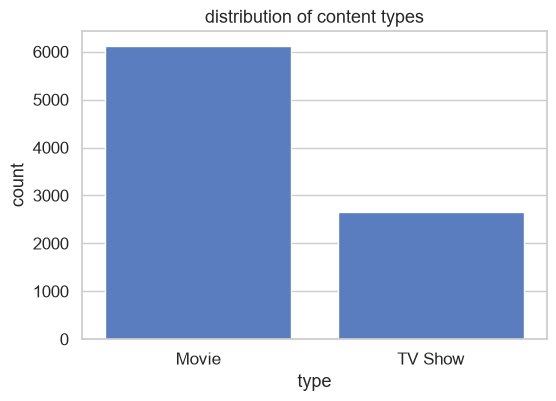

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x='type',data=df)
plt.title("distribution of content types")
plt.show()

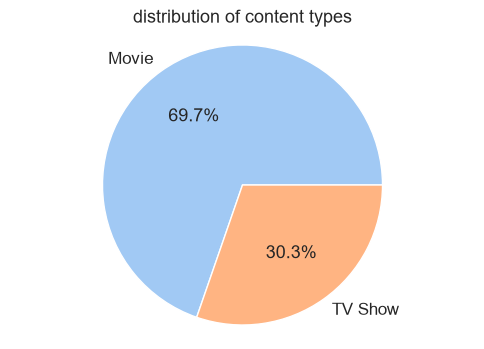

In [53]:
plt.figure(figsize=(6,4))
counts = df['type'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%.1f%%', colors=sns.color_palette('pastel'))
plt.axis('equal')
plt.title("distribution of content types")
plt.show()

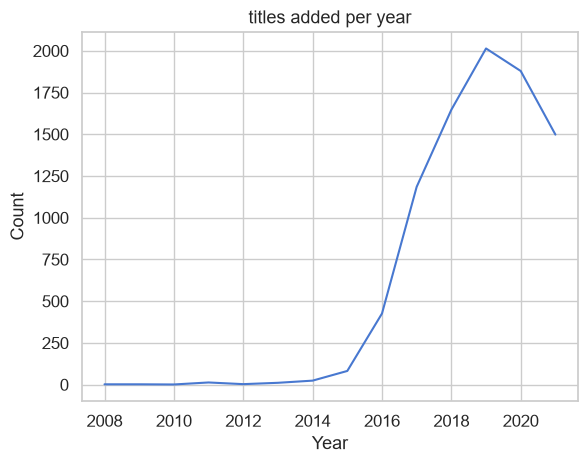

In [54]:
plt.Figure(figsize=(10,5))
df['date_added'].dt.year.value_counts().sort_index().plot(kind='line')
plt.title("titles added per year")
plt.xlabel("Year")
plt.ylabel('Count')
plt.show()

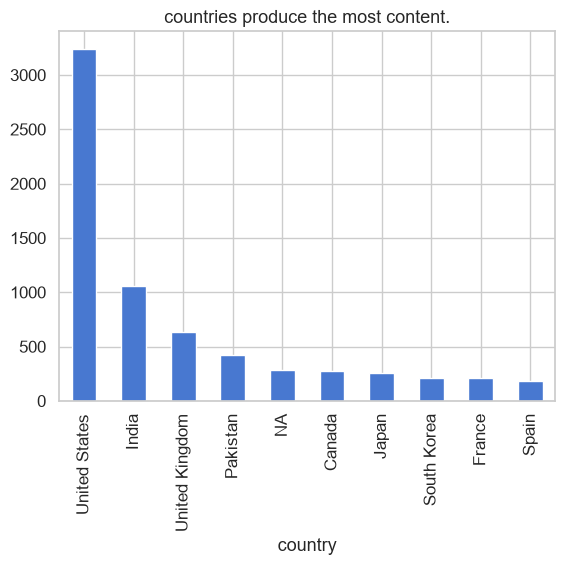

In [55]:
plt.Figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("countries produce the most content.")
plt.show()


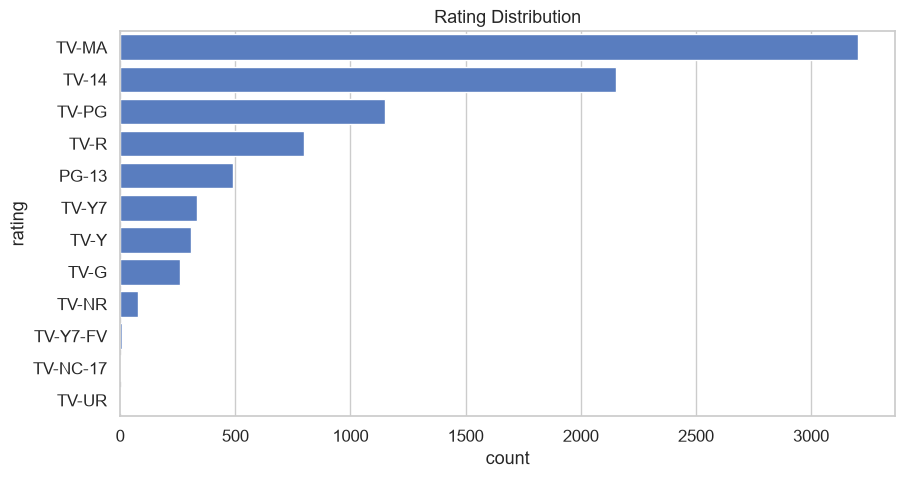

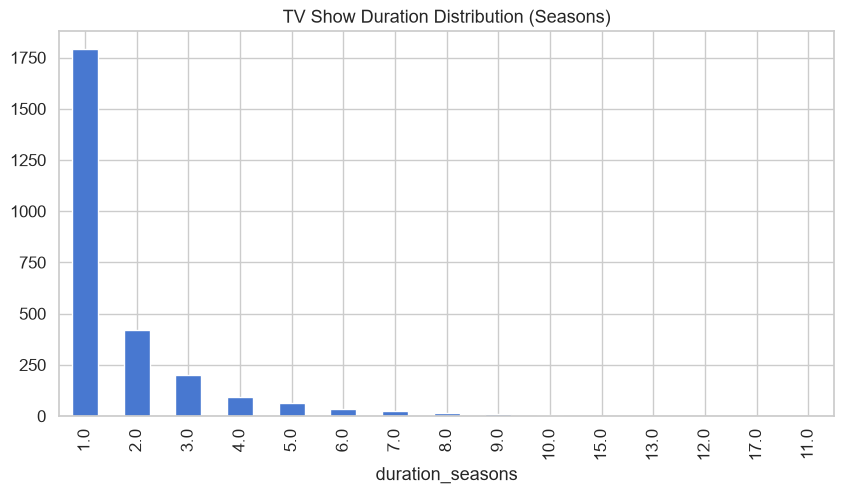

In [56]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating',data=df,order=df['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()

plt.figure(figsize=(10,5))
df[df['type']=="TV Show"]['duration_seasons'].value_counts().plot(kind='bar')
plt.title("TV Show Duration Distribution (Seasons)")
plt.show()

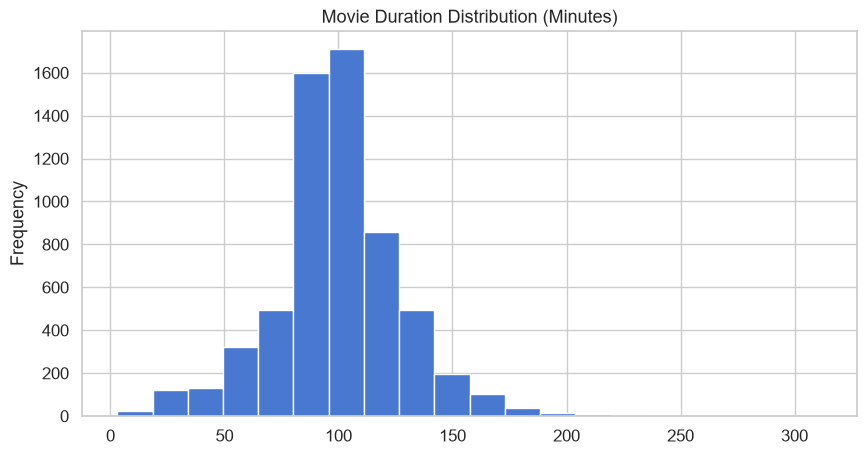

In [57]:
plt.figure(figsize=(10,5))
df[df['type']=="Movie"]['duration_minutes'].dropna().plot(kind='hist', bins=20)
plt.title("Movie Duration Distribution (Minutes)")
plt.show()

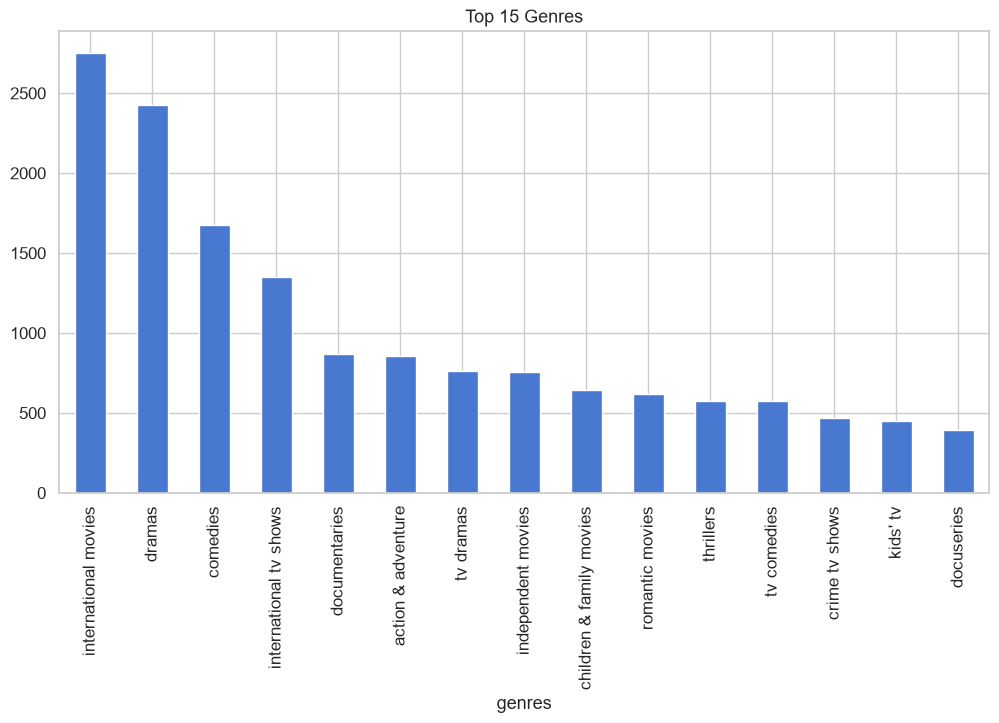

In [58]:
df_exploded = df.explode('genres')
plt.figure(figsize=(12,6))
df_exploded['genres'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Genres")
plt.show()

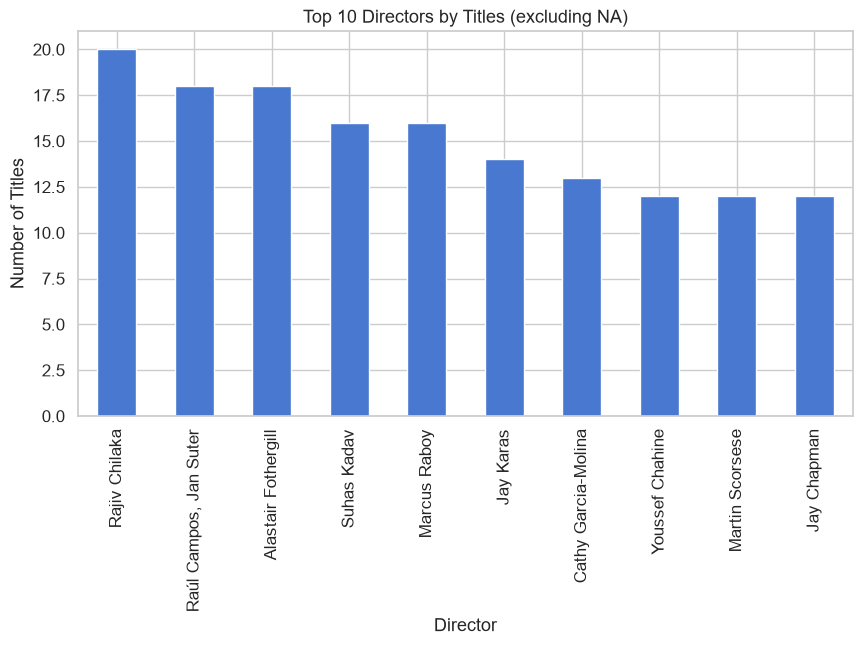

In [59]:
plt.figure(figsize=(10,5))

# Drop NA values before counting
df.loc[df['director'].notna() & (df['director'] != 'NA'), 'director'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Directors by Titles (excluding NA)")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()


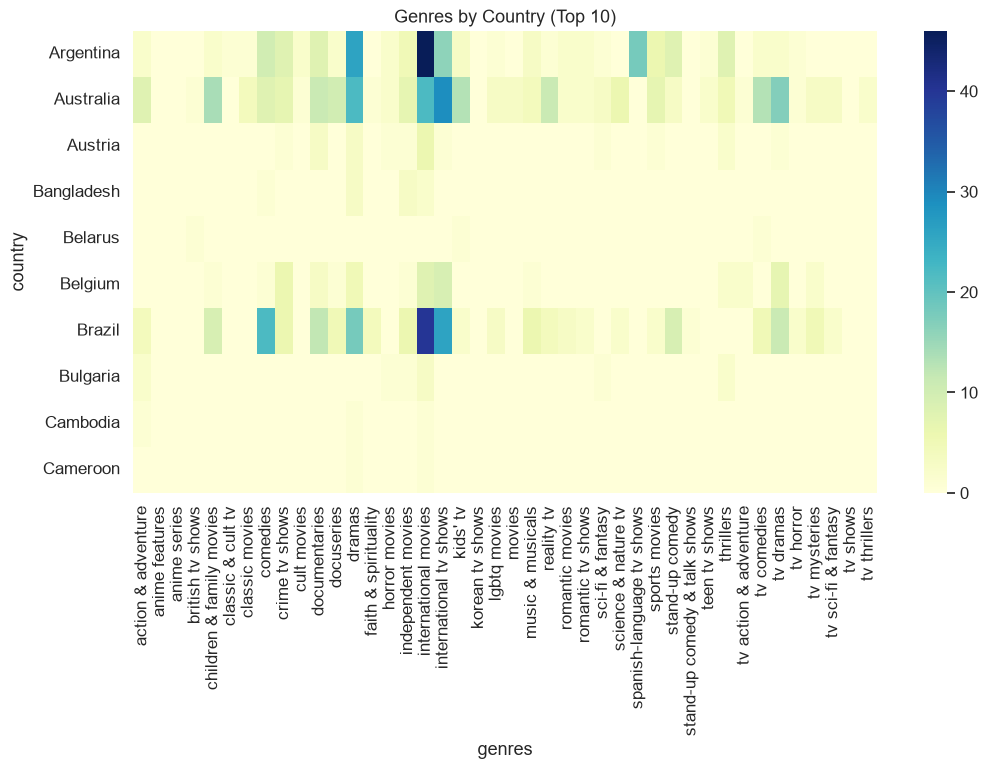

In [60]:
genre_country = df_exploded.groupby(['country','genres']).size().unstack(fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(genre_country.head(10), cmap="YlGnBu")
plt.title("Genres by Country (Top 10)")
plt.show()

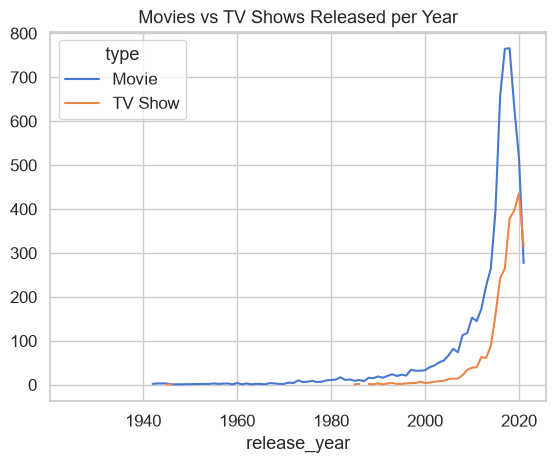

In [61]:
plt.Figure(figsize=(10,5))
df.groupby(['release_year','type']).size().unstack().plot(kind='line')
plt.title("Movies vs TV Shows Released per Year")
plt.show()

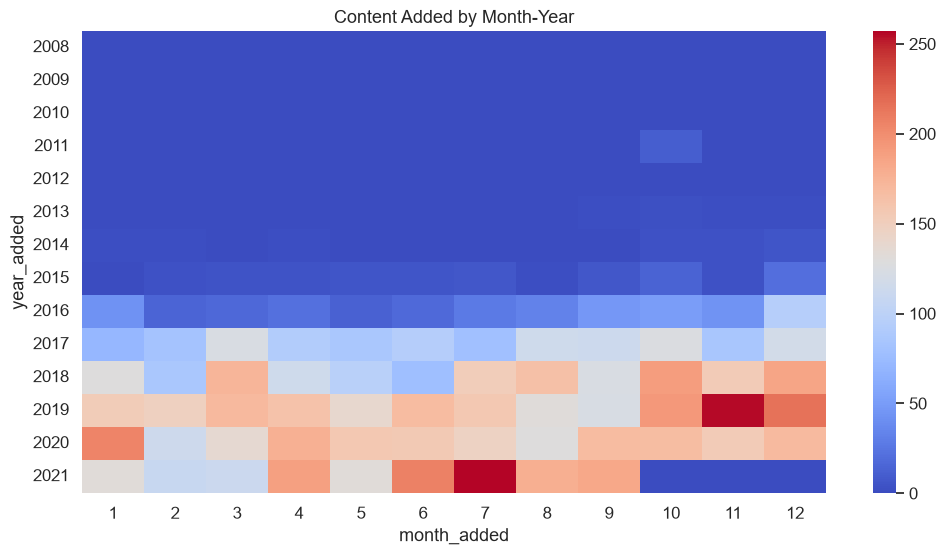

In [63]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
month_year = df.groupby(['year_added','month_added']).size().unstack(fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(month_year, cmap="coolwarm")
plt.title("Content Added by Month-Year")
plt.show()

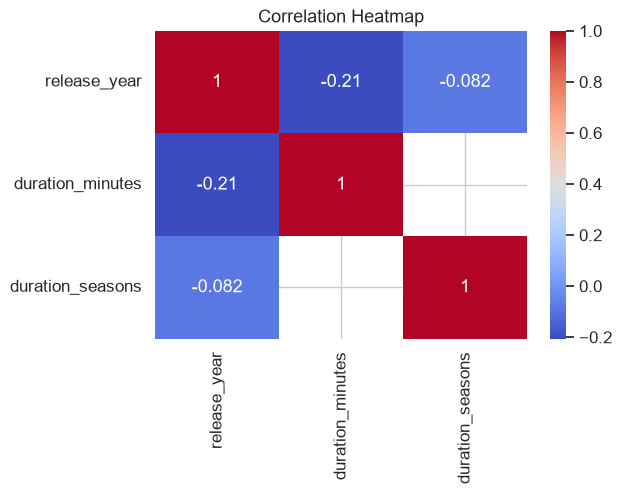

In [64]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['release_year','duration_minutes','duration_seasons']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [88]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html

# Load your cleaned dataset
try:
    df
except NameError:
    df = pd.read_csv("cleaned_netflix.csv")  # adjust filename if needed

# Normalize columns
if 'date_added' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['date_added']):
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
if 'year_added' not in df.columns:
    df['year_added'] = df['date_added'].dt.year
if 'month_added' not in df.columns:
    df['month_added'] = df['date_added'].dt.month
if 'genres' not in df.columns and 'listed_in' in df.columns:
    df['genres'] = df['listed_in'].fillna('').str.split(', ').apply(lambda lst: [g.strip().lower() for g in lst if g])
if 'duration_minutes' not in df.columns:
    df['duration_minutes'] = df['duration'].str.extract(r'(\d+)\s*min').astype(float)
if 'duration_seasons' not in df.columns:
    df['duration_seasons'] = df['duration'].str.extract(r'(\d+)\s*Season[s]?').astype(float)

# Explode genres for analysis
df_exploded = df.explode('genres')

# Initialize the app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("📺 Netflix Dashboard", style={'textAlign':'center'}),

    # Movies vs TV Shows
    dcc.Graph(
        figure=px.pie(df, names="type", title="Movies vs TV Shows")
    ),

    # Titles Added per Year
    dcc.Graph(
        figure=px.line(df.groupby('year_added').size().reset_index(name="count"),
                       x="year_added", y="count", title="Titles Added per Year")
    ),

    # Top Countries
    dcc.Graph(
        figure=px.bar(
            df['country'].value_counts().head(10).reset_index(name='count'),
            x='country', y='count', title="Top 10 Countries by Titles"
        )
    ),

    # Ratings Distribution
    dcc.Graph(
        figure=px.bar(
            df['rating'].value_counts().rename_axis('rating').reset_index(name='count'),
            x='rating', y='count', title="Ratings Distribution"
        )
    ),

    # Movie Duration Histogram
    dcc.Graph(
        figure=px.histogram(df[df['type']=="Movie"], x="duration_minutes",
                            nbins=20, title="Movie Duration Distribution (Minutes)")
    ),

    # TV Show Seasons
    dcc.Graph(
        figure=px.bar(df[df['type']=="TV Show"]['duration_seasons'].value_counts().reset_index(name='count'),
                      x='duration_seasons', y='count', title="TV Show Duration Distribution (Seasons)")
    ),

    # Release Year vs Type
    dcc.Graph(
        figure=px.line(df.groupby(['release_year','type']).size().reset_index(name="count"),
                       x="release_year", y="count", color="type",
                       title="Movies vs TV Shows Released per Year")
    ),

    # Correlation Heatmap
    dcc.Graph(
        figure=px.imshow(df[['release_year','duration_minutes','duration_seasons']].corr(),
                         text_auto=True, title="Correlation Heatmap")
    )
])

if __name__ == '__main__':
    app.run(debug=True)
